# Differentiable Growing Neural Gas on synthetic blobs

Train `DifferentiableGrowingNeuralGas` with backpropagation, call `grow()` during training, and visualize active prototypes and soft topology inline.

In [1]:
#%pip install matplotlib

%matplotlib inline

from __future__ import annotations

import matplotlib.pyplot as plt
import torch

from ngas.models import DifferentiableGrowingNeuralGas

In [3]:
def make_blobs(n_samples: int, seed: int, device: torch.device) -> torch.Tensor:
    g = torch.Generator(device="cpu")
    g.manual_seed(seed)

    centers = torch.tensor(
        [[-2.5, -1.5], [0.6, 2.0], [2.8, -0.4], [2.0, 2.8]],
        dtype=torch.float32,
    )
    chunks = []
    per_center = n_samples // centers.size(0)
    for c in centers:
        points = c + 0.42 * torch.randn(per_center, 2, generator=g)
        chunks.append(points)

    rem = n_samples - per_center * centers.size(0)
    if rem > 0:
        points = centers[0] + 0.42 * torch.randn(rem, 2, generator=g)
        chunks.append(points)

    data = torch.cat(chunks, dim=0)
    perm = torch.randperm(data.size(0), generator=g)
    data = data[perm]
    return data.to(device=device)


def plot_result(
    data: torch.Tensor,
    model: DifferentiableGrowingNeuralGas,
    losses: list[float],
    node_counts: list[int],
    edge_threshold: float = 0.45,
) -> None:
    x = data.cpu()
    pred = model.predict(data).cpu()

    idx = torch.where(model.active_mask)[0]
    w = model.weights[idx].detach().cpu()
    edge_prob = model._edge_prob_matrix()[idx][:, idx].detach().cpu()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].scatter(x[:, 0], x[:, 1], c=pred, s=16, alpha=0.5, cmap="tab20")
    axes[0].scatter(w[:, 0], w[:, 1], c="black", s=85, marker="x", linewidths=2)
    for i in range(edge_prob.size(0)):
        for j in range(i + 1, edge_prob.size(1)):
            p = float(edge_prob[i, j].item())
            if p >= edge_threshold:
                axes[0].plot(
                    [w[i, 0], w[j, 0]],
                    [w[i, 1], w[j, 1]],
                    color="black",
                    linewidth=0.8 + 1.7 * p,
                    alpha=min(0.9, p),
                )
    axes[0].set_title("Active prototypes and soft edges")

    axes[1].plot(losses, color="#1d6f5f", linewidth=2)
    axes[1].set_title("Training loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")

    axes[2].step(range(1, len(node_counts) + 1), node_counts, where="post", color="#8b4513", linewidth=2)
    axes[2].set_title("Active node count")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("n_nodes")

    plt.tight_layout()
    plt.show()

epoch=2 grew=1 n_nodes=5
epoch=4 grew=1 n_nodes=6
epoch=6 grew=1 n_nodes=7
epoch=8 grew=1 n_nodes=8
epoch=10 grew=1 n_nodes=9
epoch=12 grew=1 n_nodes=10
epoch=14 grew=1 n_nodes=11
epoch=16 grew=1 n_nodes=12
epoch=18 grew=1 n_nodes=13
epoch=20 grew=1 n_nodes=14
epoch=22 grew=1 n_nodes=15
epoch=24 grew=1 n_nodes=16
epoch=26 grew=1 n_nodes=17
epoch=28 grew=1 n_nodes=18
epoch=30 grew=1 n_nodes=19
epoch=32 grew=1 n_nodes=20
epoch=34 grew=1 n_nodes=21
epoch=36 grew=1 n_nodes=22
epoch=38 grew=1 n_nodes=23
epoch=40 grew=1 n_nodes=24
epoch=40 loss=0.092760 n_nodes=24
epoch=80 loss=0.056338 n_nodes=24
n_nodes=24
quantization_error=0.364119


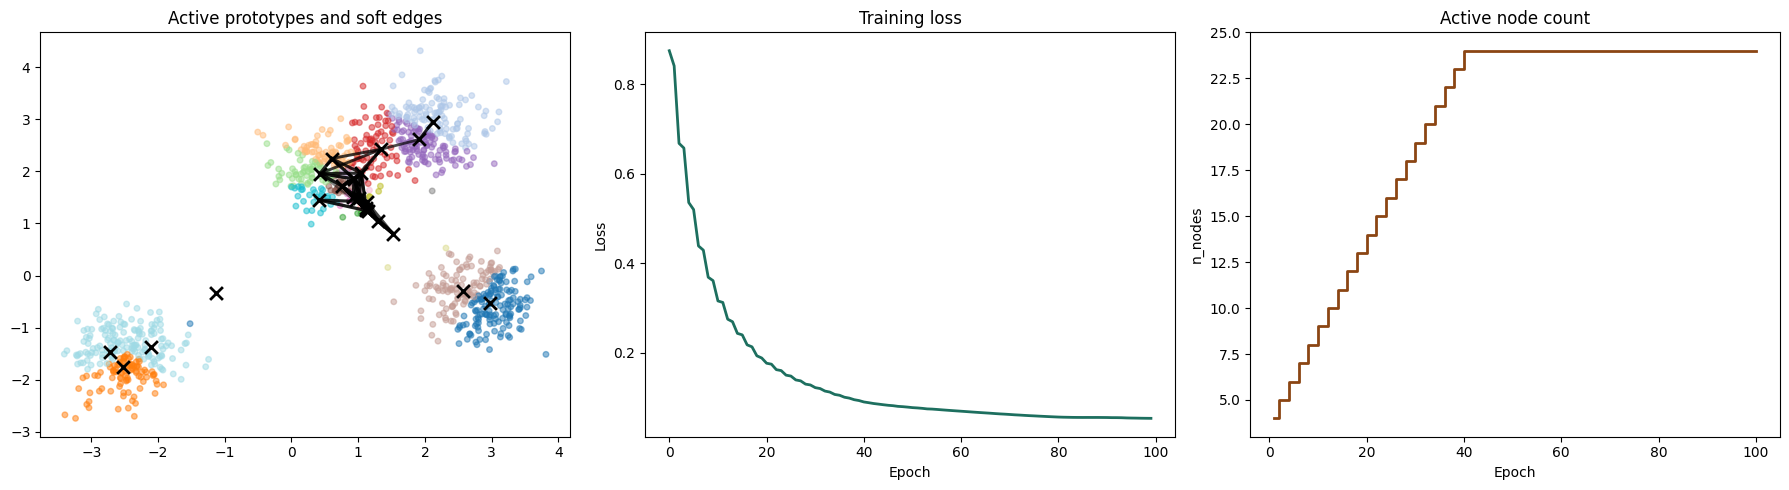

In [21]:

N_SAMPLES = 1000
MAX_NEURONS = 24
INIT_NEURONS = 4
EPOCHS = 100
LEARNING_RATE = 0.1
GROW_EVERY = 2
DISTANCE = "l2"
NEIGHBORHOOD = "inverse"
LAMBDA_VALUE = 0.5
RANK_TEMPERATURE = 0.01
TOPOLOGY_INFLUENCE = 0.1
SEED = 11
DEVICE = torch.device("cpu")


torch.manual_seed(SEED)

data = make_blobs(n_samples=N_SAMPLES, seed=SEED, device=DEVICE)

model = DifferentiableGrowingNeuralGas(
    max_neurons=MAX_NEURONS,
    input_dim=2,
    init_neurons=INIT_NEURONS,
    distance=DISTANCE,
    neighborhood=NEIGHBORHOOD,
    lambda_value=LAMBDA_VALUE,
    rank_temperature=RANK_TEMPERATURE,
    topology_influence=TOPOLOGY_INFLUENCE,
    device=DEVICE,
)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
losses = []
node_counts = []

for epoch in range(EPOCHS):
    optimizer.zero_grad()
    loss = model(data)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % GROW_EVERY == 0:
        added = model.grow(n_new=1, noise_std=0.01)
        if added > 0:
            print(f"epoch={epoch + 1} grew={added} n_nodes={model.n_nodes}")

    losses.append(float(loss.item()))
    node_counts.append(model.n_nodes)

    if (epoch + 1) % 40 == 0:
        print(f"epoch={epoch + 1} loss={loss.item():.6f} n_nodes={model.n_nodes}")

qerr = model.quantization_error(data)
print(f"n_nodes={model.n_nodes}")
print(f"quantization_error={qerr:.6f}")

plot_result(data, model, losses, node_counts)